# SRGAN + Transfer Learning on OCT Images with PyTorch
**ECGR-4116/5116: AI for Biomedical Applications**

This notebook:
1. Trains **Model A** — ResNet50 transfer learning baseline on 128×128 OCT images
2. Trains an **SRGAN** to super-resolve 32×32 → 128×128 images
3. Trains **Model B** — ResNet50 on SRGAN-generated images
4. Compares both models using F1, Accuracy, and AUC

The implementation uses PyTorch so it can use your NVIDIA GPU directly on Windows.

## 1. Setup & Imports

In [1]:
import os
import random
from glob import glob

import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, TensorDataset
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights, VGG19_Weights

import warnings
warnings.filterwarnings('ignore')

# GPU check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    torch.backends.cudnn.benchmark = True

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---- CHANGE THIS to your local data folder ----
DATA_DIR = './data'

IMG_SIZE = 128
LR_SIZE = 32
BATCH_SIZE = 32
EPOCHS_A = 50
EPOCHS_B = 150
SRGAN_EPOCHS = 50
CLASSES = ['DME', 'DRUSEN', 'NORMAL']
NUM_CLASSES = len(CLASSES)
print('Setup complete.')

Device: cuda
GPU: NVIDIA GeForce RTX 4070
Setup complete.


## 2. Data Loading, Split & Visualization

In [2]:
def load_images(data_dir, split='train', img_size=128):
    """Load images from split subfolders and return arrays + labels."""
    images, labels = [], []
    for label_idx, cls in enumerate(CLASSES):
        folder = os.path.join(data_dir, split, cls)
        paths = glob(os.path.join(folder, '*.*'))
        print(f'  {split}/{cls}: {len(paths)} images found')
        for path in paths:
            img = cv2.imread(path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(label_idx)
    images = np.array(images, dtype=np.float32) / 255.0
    labels = np.array(labels, dtype=np.int64)
    return images, labels

print('Loading training images...')
X_all, y_all = load_images(DATA_DIR, split='train', img_size=IMG_SIZE)
print(f'Total loaded: {len(X_all)} images, shape: {X_all.shape}')

# 70/30 train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.30, random_state=SEED, stratify=y_all
)
# Further split training → 80% train / 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=SEED, stratify=y_train
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

Loading training images...
  train/DME: 796 images found
  train/DRUSEN: 502 images found
  train/NORMAL: 970 images found
Total loaded: 2268 images, shape: (2268, 128, 128, 3)
Train: 1269 | Val: 318 | Test: 681


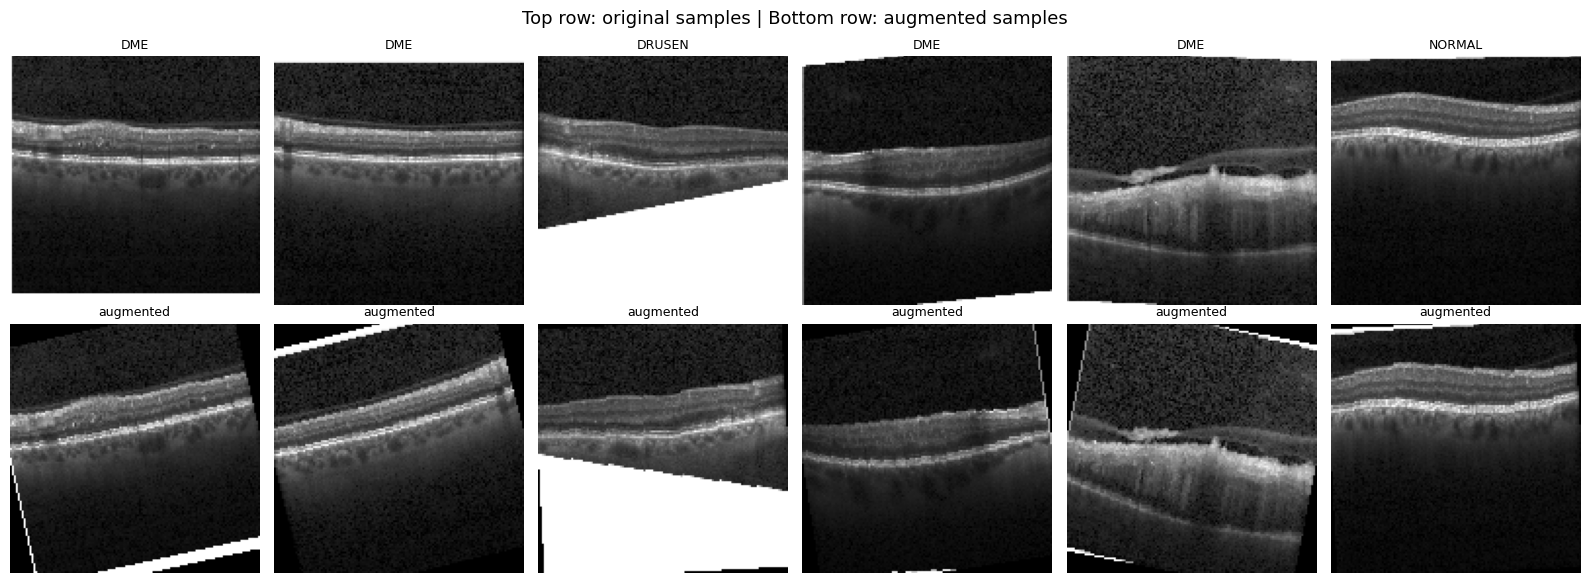

Augmentation samples saved.


In [3]:
# Visualize sample images with augmentation preview
train_augment = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
])

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Top row: original samples | Bottom row: augmented samples', fontsize=13)

for col in range(6):
    idx = np.random.randint(len(X_train))
    orig = X_train[idx]
    aug = np.array(train_augment((orig * 255).astype(np.uint8))) / 255.0
    cls_name = CLASSES[y_train[idx]]

    axes[0, col].imshow(orig)
    axes[0, col].set_title(cls_name, fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(np.clip(aug, 0, 1))
    axes[1, col].set_title('augmented', fontsize=9)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_samples.png', dpi=100)
plt.show()
print('Augmentation samples saved.')

## 3. Model A — ResNet50 Transfer Learning (128×128)

In [4]:
class ResNetClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, trainable_base=False):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2
        backbone = models.resnet50(weights=weights)
        if not trainable_base:
            for param in backbone.parameters():
                param.requires_grad = False
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
        self.model = backbone

    def forward(self, x):
        return self.model(x)


def build_resnet_classifier(num_classes=NUM_CLASSES, trainable_base=False):
    return ResNetClassifier(num_classes=num_classes, trainable_base=trainable_base)


model_A = build_resnet_classifier(num_classes=NUM_CLASSES)
model_A.to(device)
print(model_A)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\andre/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100.0%


ResNetClassifier(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
   

In [5]:
# ImageNet normalization for pretrained ResNet50
imagenet_mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
imagenet_std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def normalize_images(images):
    return ((images - imagenet_mean) / imagenet_std).astype(np.float32)


def to_tensor_dataset(images, labels, augment=False):
    if augment:
        augmented = []
        for image in images:
            transformed = train_augment((image * 255).astype(np.uint8))
            augmented.append(np.array(transformed) / 255.0)
        images = np.array(augmented, dtype=np.float32)
    images = normalize_images(images)
    tensor_x = torch.from_numpy(images).permute(0, 3, 1, 2).float()
    tensor_y = torch.from_numpy(labels).long()
    return TensorDataset(tensor_x, tensor_y)


train_dataset_A = to_tensor_dataset(X_train, y_train, augment=True)
val_dataset_A = to_tensor_dataset(X_val, y_val, augment=False)
train_loader_A = DataLoader(train_dataset_A, batch_size=BATCH_SIZE, shuffle=True)
val_loader_A = DataLoader(val_dataset_A, batch_size=BATCH_SIZE, shuffle=False)

criterion_cls = nn.CrossEntropyLoss()
optimizer_A = torch.optim.Adam(filter(lambda p: p.requires_grad, model_A.parameters()), lr=1e-4)

print('Training Model A...')
history_A = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(1, EPOCHS_A + 1):
    model_A.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_x, batch_y in train_loader_A:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer_A.zero_grad()
        logits = model_A(batch_x)
        loss = criterion_cls(logits, batch_y)
        loss.backward()
        optimizer_A.step()

        running_loss += loss.item() * batch_x.size(0)
        preds = logits.argmax(dim=1)
        train_correct += (preds == batch_y).sum().item()
        train_total += batch_y.size(0)

    model_A.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader_A:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            logits = model_A(batch_x)
            loss = criterion_cls(logits, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == batch_y).sum().item()
            val_total += batch_y.size(0)

    train_loss = running_loss / train_total
    val_loss = val_loss / val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    history_A['loss'].append(train_loss)
    history_A['val_loss'].append(val_loss)
    history_A['accuracy'].append(train_acc)
    history_A['val_accuracy'].append(val_acc)

    print(f'Epoch {epoch:03d}/{EPOCHS_A} | loss {train_loss:.4f} | acc {train_acc:.4f} | val_loss {val_loss:.4f} | val_acc {val_acc:.4f}')

print('Model A training complete.')

Training Model A...
Epoch 001/50 | loss 1.0792 | acc 0.4192 | val_loss 1.0662 | val_acc 0.4403
Epoch 002/50 | loss 1.0225 | acc 0.4500 | val_loss 0.9851 | val_acc 0.4591
Epoch 003/50 | loss 0.9784 | acc 0.5004 | val_loss 0.9137 | val_acc 0.5346
Epoch 004/50 | loss 0.9116 | acc 0.5745 | val_loss 0.8289 | val_acc 0.6101
Epoch 005/50 | loss 0.8330 | acc 0.6478 | val_loss 0.7493 | val_acc 0.7327
Epoch 006/50 | loss 0.7475 | acc 0.7116 | val_loss 0.6571 | val_acc 0.7516
Epoch 007/50 | loss 0.6639 | acc 0.7597 | val_loss 0.6089 | val_acc 0.7704
Epoch 008/50 | loss 0.6068 | acc 0.7723 | val_loss 0.5704 | val_acc 0.7830
Epoch 009/50 | loss 0.5473 | acc 0.8117 | val_loss 0.5518 | val_acc 0.7673
Epoch 010/50 | loss 0.5299 | acc 0.8077 | val_loss 0.5224 | val_acc 0.7925
Epoch 011/50 | loss 0.4915 | acc 0.8172 | val_loss 0.4611 | val_acc 0.8145
Epoch 012/50 | loss 0.4492 | acc 0.8424 | val_loss 0.4622 | val_acc 0.8365
Epoch 013/50 | loss 0.4445 | acc 0.8479 | val_loss 0.4439 | val_acc 0.8396
Epoch

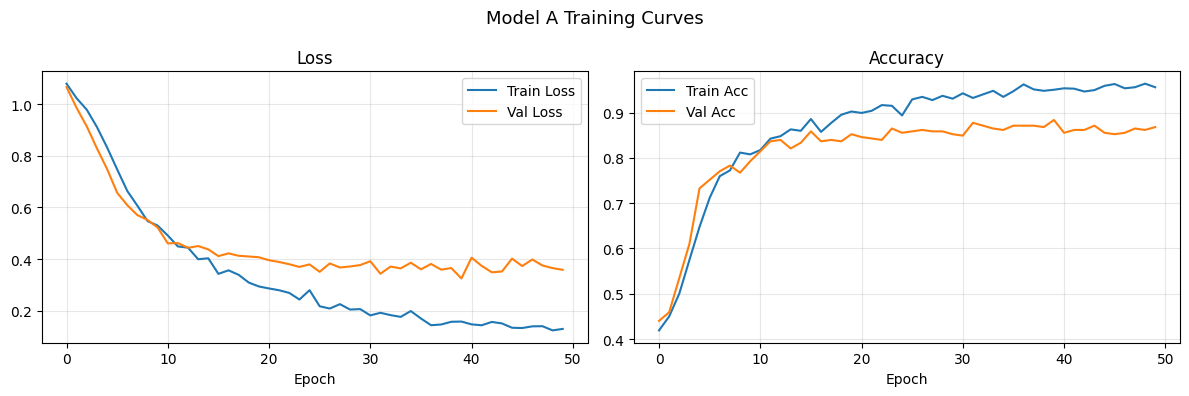

In [6]:
def plot_history(history, title='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{title} Training Curves', fontsize=13)

    axes[0].plot(history['loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['accuracy'], label='Train Acc')
    axes[1].plot(history['val_accuracy'], label='Val Acc')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_curves.png', dpi=100)
    plt.show()


plot_history(history_A, 'Model A')

## 4. SRGAN — Super-Resolution (32×32 → 128×128)

In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


class UpsampleBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels * 4, kernel_size=3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU(),
        )

    def forward(self, x):
        return self.block(x)


class GeneratorSRGAN(nn.Module):
    def __init__(self, n_residual=8):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=9, padding=4),
            nn.PReLU(),
        )
        self.residuals = nn.Sequential(*[ResidualBlock(64) for _ in range(n_residual)])
        self.mid = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
        )
        self.upsample = nn.Sequential(
            UpsampleBlock(64),
            UpsampleBlock(64),
        )
        self.output = nn.Sequential(
            nn.Conv2d(64, 3, kernel_size=9, padding=4),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x0 = self.initial(x)
        x = self.residuals(x0)
        x = self.mid(x)
        x = x + x0
        x = self.upsample(x)
        return self.output(x)


class DiscriminatorSRGAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 1),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x).squeeze(1)


def build_generator():
    return GeneratorSRGAN()


def build_discriminator():
    return DiscriminatorSRGAN()


generator = build_generator().to(device)
discriminator = build_discriminator().to(device)
print(generator)
print(discriminator)

GeneratorSRGAN(
  (initial): Sequential(
    (0): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (1): PReLU(num_parameters=1)
  )
  (residuals): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PReLU(num_parameters=1)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): PReLU(num_parameters=1)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-

In [8]:
class VGGFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        weights = VGG19_Weights.IMAGENET1K_V1
        vgg = models.vgg19(weights=weights)
        self.features = nn.Sequential(*list(vgg.features.children())[:16]).eval()
        for param in self.features.parameters():
            param.requires_grad = False
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x - self.mean) / self.std
        return self.features(x)


feature_extractor = VGGFeatureExtractor().to(device)
feature_extractor.eval()

print('Preparing LR/HR pairs for SRGAN...')
X_hr = X_train.copy()
X_lr = np.array([
    cv2.resize(img, (LR_SIZE, LR_SIZE), interpolation=cv2.INTER_AREA) for img in X_hr
], dtype=np.float32)

X_hr_tensor = torch.from_numpy(X_hr).permute(0, 3, 1, 2).float()
X_lr_tensor = torch.from_numpy(X_lr).permute(0, 3, 1, 2).float()

train_dataset_sr = TensorDataset(X_lr_tensor, X_hr_tensor)
train_loader_sr = DataLoader(train_dataset_sr, batch_size=BATCH_SIZE, shuffle=True)

print(f'LR shape: {X_lr.shape}, HR shape: {X_hr.shape}')

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\andre/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth
100.0%


Preparing LR/HR pairs for SRGAN...
LR shape: (1269, 32, 32, 3), HR shape: (1269, 128, 128, 3)


In [9]:
gen_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4, betas=(0.9, 0.999))
disc_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.9, 0.999))
bce_loss = nn.BCEWithLogitsLoss()
mse_loss = nn.MSELoss()


def train_step_srgan(lr_imgs, hr_imgs):
    batch_size = lr_imgs.size(0)
    real_labels = torch.ones(batch_size, device=device)
    fake_labels = torch.zeros(batch_size, device=device)

    # Train Discriminator
    disc_optimizer.zero_grad()
    with torch.no_grad():
        fake_hr = generator(lr_imgs)
    real_logits = discriminator(hr_imgs)
    fake_logits = discriminator(fake_hr)
    d_loss = bce_loss(real_logits, real_labels) + bce_loss(fake_logits, fake_labels)
    d_loss.backward()
    disc_optimizer.step()

    # Train Generator
    gen_optimizer.zero_grad()
    fake_hr = generator(lr_imgs)
    fake_logits = discriminator(fake_hr)
    adv_loss = bce_loss(fake_logits, real_labels)
    real_features = feature_extractor(hr_imgs)
    fake_features = feature_extractor(fake_hr)
    percep_loss = mse_loss(fake_features, real_features)
    g_loss = 1e-3 * adv_loss + percep_loss
    g_loss.backward()
    gen_optimizer.step()

    return d_loss.item(), g_loss.item()


SRGAN_EPOCHS = 50
SAVE_EVERY_N = 5
os.makedirs('checkpoints/srgan', exist_ok=True)

d_losses, g_losses = [], []

print(f'Starting SRGAN training for {SRGAN_EPOCHS} epochs...')
for epoch in range(1, SRGAN_EPOCHS + 1):
    generator.train()
    discriminator.train()
    epoch_d, epoch_g = [], []
    for lr_batch, hr_batch in train_loader_sr:
        lr_batch = lr_batch.to(device)
        hr_batch = hr_batch.to(device)
        d_l, g_l = train_step_srgan(lr_batch, hr_batch)
        epoch_d.append(d_l)
        epoch_g.append(g_l)

    mean_d = float(np.mean(epoch_d))
    mean_g = float(np.mean(epoch_g))
    d_losses.append(mean_d)
    g_losses.append(mean_g)

    if epoch % SAVE_EVERY_N == 0 or epoch == 1:
        torch.save(generator.state_dict(), f'checkpoints/srgan/generator_epoch_{epoch:03d}.pt')
        torch.save(discriminator.state_dict(), f'checkpoints/srgan/discriminator_epoch_{epoch:03d}.pt')
        print(f'Epoch {epoch:3d}/{SRGAN_EPOCHS} | D loss: {mean_d:.4f} | G loss: {mean_g:.4f} [saved]')
    else:
        print(f'Epoch {epoch:3d}/{SRGAN_EPOCHS} | D loss: {mean_d:.4f} | G loss: {mean_g:.4f}')

print('SRGAN training complete.')

Starting SRGAN training for 50 epochs...
Epoch   1/50 | D loss: 0.5961 | G loss: 9.7219 [saved]
Epoch   2/50 | D loss: 0.0455 | G loss: 7.4439
Epoch   3/50 | D loss: 0.0101 | G loss: 6.4354
Epoch   4/50 | D loss: 0.0057 | G loss: 5.8037
Epoch   5/50 | D loss: 0.0063 | G loss: 5.3842 [saved]
Epoch   6/50 | D loss: 0.0019 | G loss: 5.0464
Epoch   7/50 | D loss: 0.0013 | G loss: 4.7120
Epoch   8/50 | D loss: 0.0012 | G loss: 4.4495
Epoch   9/50 | D loss: 0.0008 | G loss: 4.2656
Epoch  10/50 | D loss: 0.0007 | G loss: 4.1200 [saved]
Epoch  11/50 | D loss: 0.0005 | G loss: 3.9940
Epoch  12/50 | D loss: 0.3144 | G loss: 3.8331
Epoch  13/50 | D loss: 0.0704 | G loss: 3.7576
Epoch  14/50 | D loss: 0.0077 | G loss: 3.6533
Epoch  15/50 | D loss: 0.0047 | G loss: 3.5972 [saved]
Epoch  16/50 | D loss: 0.0032 | G loss: 3.5162
Epoch  17/50 | D loss: 0.0025 | G loss: 3.4589
Epoch  18/50 | D loss: 0.0023 | G loss: 3.4285
Epoch  19/50 | D loss: 0.0017 | G loss: 3.3684
Epoch  20/50 | D loss: 0.0014 | G 

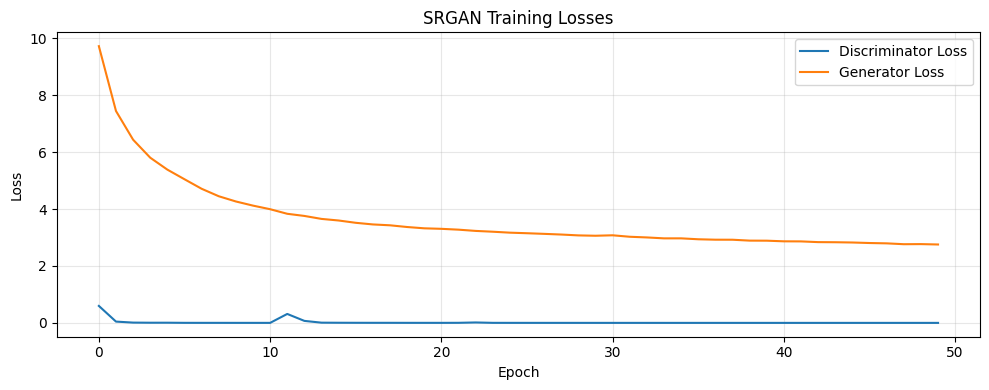

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(d_losses, label='Discriminator Loss')
plt.plot(g_losses, label='Generator Loss')
plt.title('SRGAN Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('srgan_losses.png', dpi=100)
plt.show()

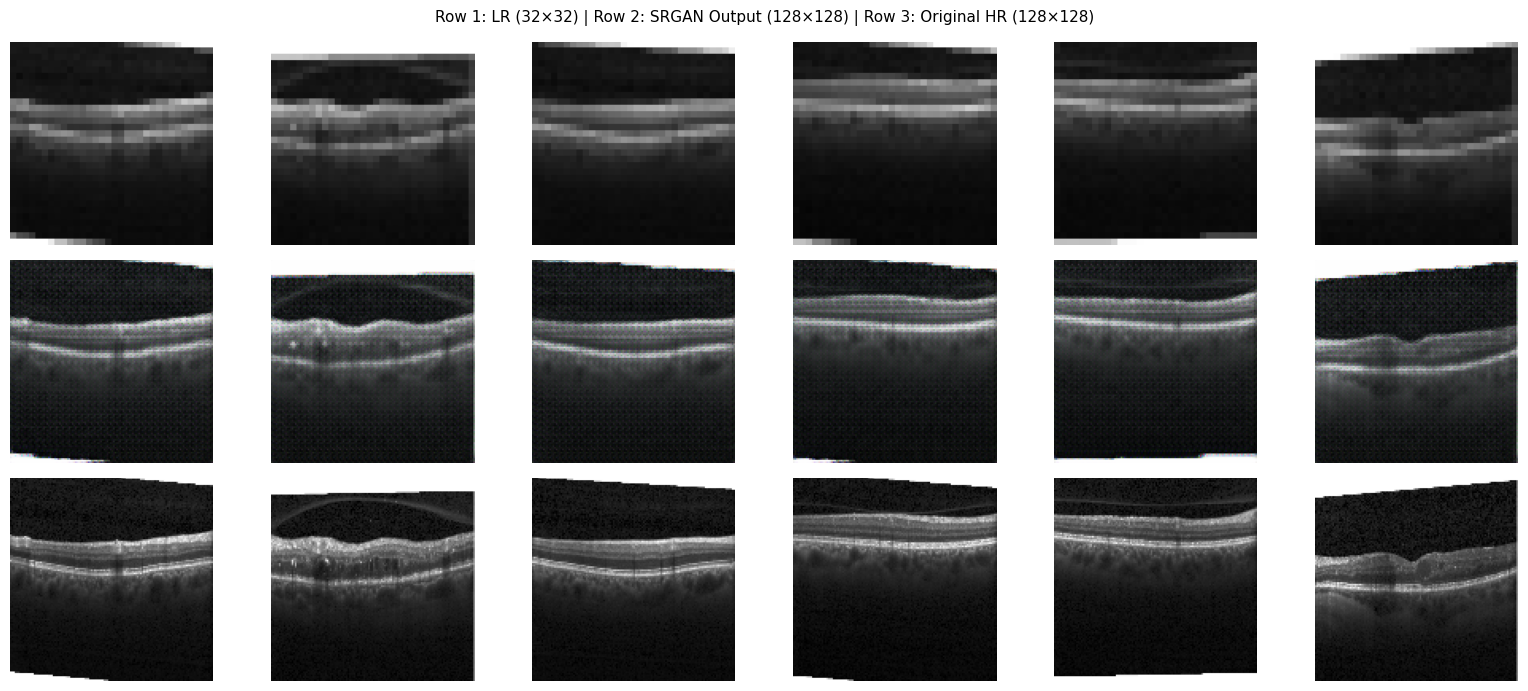

In [11]:
# Show examples: LR input vs SRGAN output vs original HR
n_examples = 6
sample_idx = np.random.choice(len(X_lr), n_examples, replace=False)

lr_samples = X_lr_tensor[sample_idx].to(device)
with torch.no_grad():
    sr_samples = generator(lr_samples).cpu().numpy()
hr_samples = X_hr_tensor[sample_idx].numpy()

fig, axes = plt.subplots(3, n_examples, figsize=(16, 7))
fig.suptitle('Row 1: LR (32×32) | Row 2: SRGAN Output (128×128) | Row 3: Original HR (128×128)', fontsize=11)

for col in range(n_examples):
    lr_disp = np.transpose(lr_samples[col].cpu().numpy(), (1, 2, 0))
    lr_disp = cv2.resize(lr_disp, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    sr_disp = np.transpose(sr_samples[col], (1, 2, 0))
    hr_disp = np.transpose(hr_samples[col], (1, 2, 0))

    axes[0, col].imshow(np.clip(lr_disp, 0, 1))
    axes[0, col].axis('off')
    axes[1, col].imshow(np.clip(sr_disp, 0, 1))
    axes[1, col].axis('off')
    axes[2, col].imshow(np.clip(hr_disp, 0, 1))
    axes[2, col].axis('off')

axes[0, 0].set_ylabel('LR input', fontsize=10)
axes[1, 0].set_ylabel('SRGAN SR', fontsize=10)
axes[2, 0].set_ylabel('Original HR', fontsize=10)
plt.tight_layout()
plt.savefig('srgan_examples.png', dpi=100)
plt.show()

## 5. Model B — ResNet50 trained on SRGAN-generated images (150+ epochs)

In [12]:
print('Generating SR images for Model B training set...')
SR_BATCH = 64

generator.eval()
X_sr_train_batches = []
with torch.no_grad():
    for i in range(0, len(X_lr_tensor), SR_BATCH):
        batch = X_lr_tensor[i:i + SR_BATCH].to(device)
        sr = generator(batch).cpu()
        X_sr_train_batches.append(sr)
X_sr_train_tensor = torch.cat(X_sr_train_batches, dim=0)

# Generate SR validation set too
X_val_lr = np.array([
    cv2.resize(img, (LR_SIZE, LR_SIZE), interpolation=cv2.INTER_AREA) for img in X_val
], dtype=np.float32)
X_val_lr_tensor = torch.from_numpy(X_val_lr).permute(0, 3, 1, 2).float()
with torch.no_grad():
    X_sr_val_tensor = generator(X_val_lr_tensor.to(device)).cpu()

print(f'SR train: {tuple(X_sr_train_tensor.shape)}, SR val: {tuple(X_sr_val_tensor.shape)}')

Generating SR images for Model B training set...
SR train: (1269, 3, 128, 128), SR val: (318, 3, 128, 128)


In [13]:
model_B = build_resnet_classifier(num_classes=NUM_CLASSES)
model_B.to(device)

optimizer_B = torch.optim.Adam(filter(lambda p: p.requires_grad, model_B.parameters()), lr=1e-4)
criterion_B = nn.CrossEntropyLoss()

train_dataset_B = TensorDataset(X_sr_train_tensor, torch.from_numpy(y_train).long())
val_dataset_B = TensorDataset(X_sr_val_tensor, torch.from_numpy(y_val).long())
train_loader_B = DataLoader(train_dataset_B, batch_size=BATCH_SIZE, shuffle=True)
val_loader_B = DataLoader(val_dataset_B, batch_size=BATCH_SIZE, shuffle=False)

print('Training Model B (150 epochs)...')
history_B = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(1, EPOCHS_B + 1):
    model_B.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    for batch_x, batch_y in train_loader_B:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer_B.zero_grad()
        logits = model_B(batch_x)
        loss = criterion_B(logits, batch_y)
        loss.backward()
        optimizer_B.step()

        running_loss += loss.item() * batch_x.size(0)
        preds = logits.argmax(dim=1)
        train_correct += (preds == batch_y).sum().item()
        train_total += batch_y.size(0)

    model_B.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader_B:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            logits = model_B(batch_x)
            loss = criterion_B(logits, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == batch_y).sum().item()
            val_total += batch_y.size(0)

    train_loss = running_loss / train_total
    val_loss = val_loss / val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total
    history_B['loss'].append(train_loss)
    history_B['val_loss'].append(val_loss)
    history_B['accuracy'].append(train_acc)
    history_B['val_accuracy'].append(val_acc)

    print(f'Epoch {epoch:03d}/{EPOCHS_B} | loss {train_loss:.4f} | acc {train_acc:.4f} | val_loss {val_loss:.4f} | val_acc {val_acc:.4f}')

print('Model B training complete.')

Training Model B (150 epochs)...
Epoch 001/150 | loss 1.0610 | acc 0.4421 | val_loss 1.0715 | val_acc 0.4308
Epoch 002/150 | loss 0.9809 | acc 0.4783 | val_loss 0.9491 | val_acc 0.6101
Epoch 003/150 | loss 0.8869 | acc 0.6013 | val_loss 0.8342 | val_acc 0.7201
Epoch 004/150 | loss 0.7812 | acc 0.7329 | val_loss 0.7275 | val_acc 0.7484
Epoch 005/150 | loss 0.6944 | acc 0.7392 | val_loss 0.6452 | val_acc 0.7830
Epoch 006/150 | loss 0.6322 | acc 0.7541 | val_loss 0.5969 | val_acc 0.8145
Epoch 007/150 | loss 0.5665 | acc 0.8014 | val_loss 0.5531 | val_acc 0.8428
Epoch 008/150 | loss 0.5125 | acc 0.8251 | val_loss 0.5164 | val_acc 0.8333
Epoch 009/150 | loss 0.4782 | acc 0.8353 | val_loss 0.4815 | val_acc 0.8491
Epoch 010/150 | loss 0.4332 | acc 0.8511 | val_loss 0.4498 | val_acc 0.8553
Epoch 011/150 | loss 0.4088 | acc 0.8582 | val_loss 0.4416 | val_acc 0.8491
Epoch 012/150 | loss 0.3887 | acc 0.8716 | val_loss 0.4019 | val_acc 0.8522
Epoch 013/150 | loss 0.3776 | acc 0.8747 | val_loss 0.3

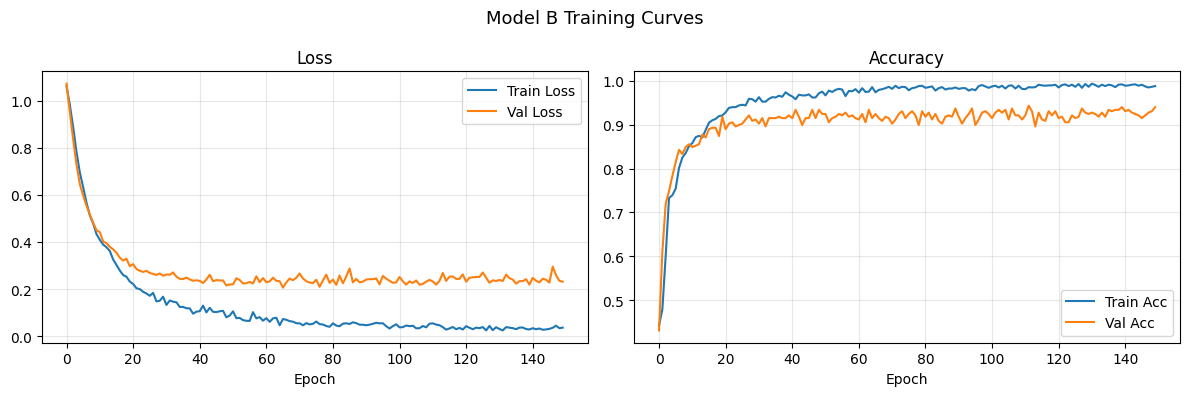

In [14]:
plot_history(history_B, 'Model B')

## 6. Evaluation — Confusion Matrix, F1, Accuracy, AUC


===== Model A =====
Accuracy : 0.8414
F1 Score : 0.8385
AUC-ROC  : 0.9613
              precision    recall  f1-score   support

         DME       0.90      0.72      0.80       239
      DRUSEN       0.82      0.81      0.82       151
      NORMAL       0.82      0.96      0.88       291

    accuracy                           0.84       681
   macro avg       0.85      0.83      0.83       681
weighted avg       0.85      0.84      0.84       681



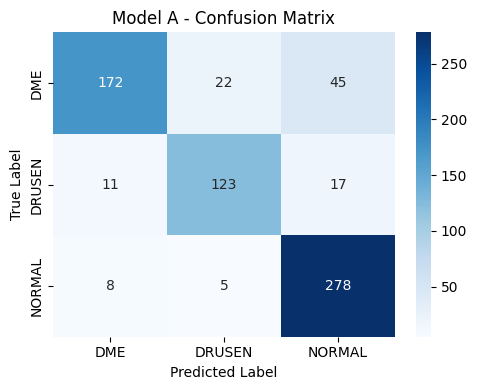

Generating SR test images for Model B...

===== Model B =====
Accuracy : 0.9134
F1 Score : 0.9134
AUC-ROC  : 0.9775
              precision    recall  f1-score   support

         DME       0.89      0.92      0.90       239
      DRUSEN       0.87      0.85      0.86       151
      NORMAL       0.95      0.94      0.95       291

    accuracy                           0.91       681
   macro avg       0.91      0.90      0.90       681
weighted avg       0.91      0.91      0.91       681



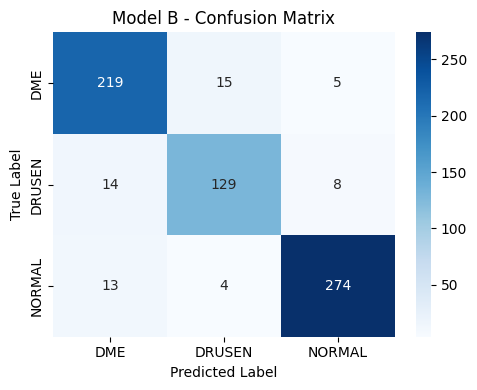

In [15]:
def evaluate_model(model, X_test, y_test, model_name='Model'):
    """Compute and display all evaluation metrics."""
    model.eval()
    y_prob = []
    y_true = []
    y_pred = []

    dataset = DataLoader(TensorDataset(X_test, torch.from_numpy(y_test).long()), batch_size=BATCH_SIZE, shuffle=False)
    with torch.no_grad():
        for batch_x, batch_y in dataset:
            batch_x = batch_x.to(device)
            logits = model(batch_x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            y_prob.append(probs)
            y_true.append(batch_y.numpy())
            y_pred.append(probs.argmax(axis=1))

    y_prob = np.concatenate(y_prob, axis=0)
    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    auc = roc_auc_score(y_true_bin, y_prob, multi_class='ovr')
    cm = confusion_matrix(y_true, y_pred)

    print(f'\n===== {model_name} =====')
    print(f'Accuracy : {acc:.4f}')
    print(f'F1 Score : {f1:.4f}')
    print(f'AUC-ROC  : {auc:.4f}')
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ","_")}_confusion_matrix.png', dpi=100)
    plt.show()

    return acc, f1, auc, y_prob, y_true, y_pred


# Evaluate Model A on original test images
X_test_tensor = torch.from_numpy(normalize_images(X_test)).permute(0, 3, 1, 2).float()
acc_A, f1_A, auc_A, prob_A, y_true_A, pred_A = evaluate_model(model_A, X_test_tensor, y_test, 'Model A')

# Generate SR test images for Model B
print('Generating SR test images for Model B...')
X_test_lr = np.array([
    cv2.resize(img, (LR_SIZE, LR_SIZE), interpolation=cv2.INTER_AREA) for img in X_test
], dtype=np.float32)
X_test_lr_tensor = torch.from_numpy(X_test_lr).permute(0, 3, 1, 2).float()
with torch.no_grad():
    X_sr_test_tensor = generator(X_test_lr_tensor.to(device)).cpu()

# Evaluate Model B on SR test images
acc_B, f1_B, auc_B, prob_B, y_true_B, pred_B = evaluate_model(model_B, X_sr_test_tensor, y_test, 'Model B')

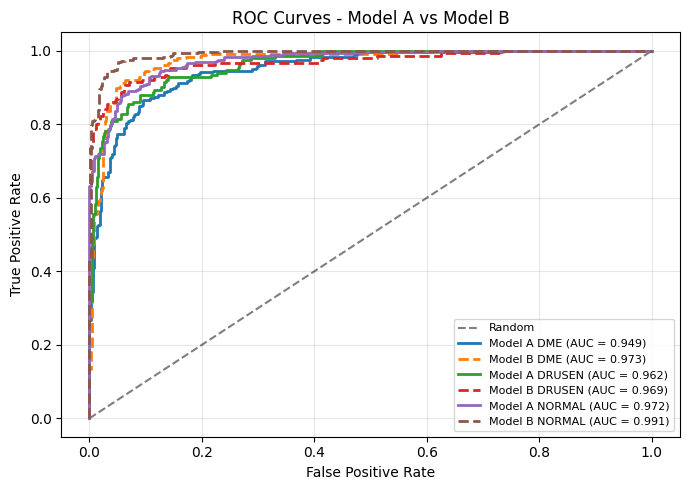


========== Final Comparison ==========
Metric          Model A    Model B
----------------------------------
Accuracy         0.8414     0.9134
F1 Score         0.8385     0.9134
AUC-ROC          0.9613     0.9775


In [16]:
# Side-by-side ROC curves
fpr_A = {}
tpr_A = {}
fpr_B = {}
tpr_B = {}
auc_per_class_A = []
auc_per_class_B = []

for class_idx in range(NUM_CLASSES):
    fpr_A[class_idx], tpr_A[class_idx], _ = roc_curve((y_test == class_idx).astype(int), prob_A[:, class_idx])
    fpr_B[class_idx], tpr_B[class_idx], _ = roc_curve((y_test == class_idx).astype(int), prob_B[:, class_idx])
    auc_per_class_A.append(roc_auc_score((y_test == class_idx).astype(int), prob_A[:, class_idx]))
    auc_per_class_B.append(roc_auc_score((y_test == class_idx).astype(int), prob_B[:, class_idx]))

plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
for class_idx, class_name in enumerate(CLASSES):
    plt.plot(fpr_A[class_idx], tpr_A[class_idx], linewidth=2, label=f'Model A {class_name} (AUC = {auc_per_class_A[class_idx]:.3f})')
    plt.plot(fpr_B[class_idx], tpr_B[class_idx], linewidth=2, linestyle='--', label=f'Model B {class_name} (AUC = {auc_per_class_B[class_idx]:.3f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model A vs Model B')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=100)
plt.show()

print('\n========== Final Comparison ==========' )
print(f'{"Metric":<12} {"Model A":>10} {"Model B":>10}')
print('-' * 34)
print(f'{"Accuracy":<12} {acc_A:>10.4f} {acc_B:>10.4f}')
print(f'{"F1 Score":<12} {f1_A:>10.4f} {f1_B:>10.4f}')
print(f'{"AUC-ROC":<12} {auc_A:>10.4f} {auc_B:>10.4f}')
print('======================================')